# Implementation of Deep Q-Learning

This notebook includes an implementation of the Deep Q-learning algorithm for the Lunar Lander problem (see [Lunar Lander documentation](https://gymnasium.farama.org/environments/box2d/lunar_lander/)).


## Authors

* Pablo Tsang Chang: pablo.tsang@alumnos.upm.es
* Diego Mateo Fernández: diego.mateofer@alumnos.upm.es
* Alejandro Escorial Aparicio: alejandro.escorial@alumnos.upm.es
* Oliver Arnaldo Anderson Llorens:  oliver.anderson@alumnos.upm.es

## Libraries

In [ ]:
!pip install gymnasium[classic-control]

import gymnasium as gym
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
import time
import random
import math

In [ ]:
!pip install gymnasium[box2d]

## Hyperparameters

In [ ]:
# Learning rate
LEARNING_RATE = 0.0005
# Batch size
BATCH_SIZE = 256
# Discount factor gamma
GAMMA = 0.99
# Size of the replay buffer that stores transitions
MEMORY_SIZE = 70000
# Values related to the epsilon-greedy policy
EXPLORATION_RATE_MAX = 1
EXPLORATION_RATE_MIN = 0.02
EXPLORATION_RATE_DECAY = 0.98
# Maximum number of episodes for training
MAX_EPISODES_FOR_TRAINING = 500
# Training goal
TRAINING_GOAL = 220
# Number of episodes to validate the training goal
EPISODES_TO_CHECK_TRAINING_GOAL = 10
# Number of episodes to evaluate the model performance
EPISODES_TO_EVALUATE_MODEL_PERFORMANCE = 30
# Number of steps required to update the target network
UPDATE_TARGET_EVERY_K_STEPS = 1000

## Class ReplayMemory

Memory of transitions for experience replay.

In [ ]:
class ReplayMemory:
    def __init__(self, number_of_observations):
        self.max_size = MEMORY_SIZE # Limit size
        self.states = np.zeros((self.max_size, number_of_observations))
        self.states_next = np.zeros((self.max_size, number_of_observations))
        self.actions = np.zeros(self.max_size, dtype=np.int32)
        self.rewards = np.zeros(self.max_size)
        self.terminal_states = np.zeros(self.max_size, dtype=bool)
        self.current_size = 0
        self.ptr = 0 # Pointer so that the buffer is circular and past experiences are erased (FIFO) to give more importance to recent experiences

    def store_transition(self, state, action, reward, state_next, terminal_state):
        # Save the pointer's position
        i = self.ptr
        self.states[i] = state
        self.states_next[i] = state_next
        self.actions[i] = action
        self.rewards[i] = reward
        self.terminal_states[i] = terminal_state


        self.ptr = (self.ptr + 1) % self.max_size # Returns to 0 if it reaches the end
        self.current_size = min(self.current_size + 1, self.max_size) # Current size grows up to the maximum

    def sample_memory(self, batch_size):
        # Generate a batch of transitions for the replay memory
        batch = np.random.choice(self.current_size, batch_size)
        states = self.states[batch]
        states_next = self.states_next[batch]
        rewards = self.rewards[batch]
        actions = self.actions[batch]
        terminal_states = self.terminal_states[batch]
        return states, actions, rewards, states_next, terminal_states

## Class DQN

Reinforcement learning agent with a Deep Q-Network.

In [ ]:
class DQN:

    def __init__(self, number_of_observations, number_of_actions):
        self.number_of_actions = number_of_actions
        self.number_of_observations = number_of_observations
        self.scores = []
        self.memory = ReplayMemory(number_of_observations)


        self.model = self._build_model()
        self.target_model = self._build_model() # Target Network to to calculate the Q-values of the next state

        # Initialize both networks with the same weights
        self.update_target_network()

    def _build_model(self):
        # Model with 256 neurons in the hidden layers and Huber as a loss function
        model = keras.models.Sequential()
        model.add(keras.layers.InputLayer(shape=(int(self.number_of_observations),)))
        model.add(keras.layers.Dense(256, activation="relu",kernel_initializer="he_normal"))
        model.add(keras.layers.Dense(256, activation="relu",kernel_initializer="he_normal"))
        model.add(keras.layers.Dense(int(self.number_of_actions), activation="linear"))
        model.compile(loss=keras.losses.Huber(), optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))
        return model

    def update_target_network(self):
        # Dumps the weights of the main network to the target network
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, terminal_state):
        # Stores a tuple (s, a, r, s')
        state = np.reshape(state, [1, self.number_of_observations])
        next_state = np.reshape(next_state, [1, self.number_of_observations])
        self.memory.store_transition(state, action, reward, next_state, terminal_state)

    def select_epsilon_greedy_policy(self, state, exploration_rate):
        # Generates an action for a given state using an epsilon-greedy policy
        if np.random.rand() < exploration_rate:
            return random.randrange(self.number_of_actions)
        else:
            state = np.reshape(state, [1, self.number_of_observations])
            q_values = self.model(state).numpy()
            return np.argmax(q_values[0])

    def select_greedy_policy(self, state):
        # Generates an action for a given state using a greedy policy
        state = np.reshape(state, [1, self.number_of_observations])
        q_values = self.model(state).numpy()
        return np.argmax(q_values[0])

    def learn(self):
        # Learns the Q value using a batch of transitions from replay memory
        if self.memory.current_size < BATCH_SIZE: return

        states, actions, rewards, next_states, terminal_states = self.memory.sample_memory(BATCH_SIZE)

        q_targets = self.model(states).numpy()
        # Predict the value of the next state with the Target Network (breaks correlation and stabilizes the model)
        q_next_states = self.target_model(next_states).numpy()

        for i in range(BATCH_SIZE):
             if (terminal_states[i]):
                  q_targets[i][actions[i]] = rewards[i]
             else:
                  q_targets[i][actions[i]] = rewards[i] + GAMMA * np.max(q_next_states[i])

        self.model.train_on_batch(states, q_targets)

    # DDQN implementation
    '''
        def learn(self):
        if self.memory.current_size < BATCH_SIZE: return

        states, actions, rewards, next_states, terminal_states = self.memory.sample_memory(BATCH_SIZE)

        q_targets = self.model(states).numpy()

        # Uses the main model to select the best action
        actions_from_main_model = np.argmax(self.model(next_states).numpy(), axis=1)

        # The target model evaluates the Q value
        q_values_from_target_model = self.target_model(next_states).numpy()

        for i in range(BATCH_SIZE):
             if (terminal_states[i]):
                  q_targets[i][actions[i]] = rewards[i]
             else:
                  q_targets[i][actions[i]] = rewards[i] + GAMMA * q_values_from_target_model[i][actions_from_main_model[i]]

        self.model.train_on_batch(states, q_targets)
    '''

    def add_score(self, score):
        # Add the score to the list
        self.scores.append(score)

    def delete_scores(self):
        # Delete the scores
        self.scores = []

    def average_score(self, number_of_episodes):
        # Compute the average of the scores
        index = len(agent.scores) - number_of_episodes
        return np.mean(self.scores[max(0,index):(len(agent.scores))])

    def display_scores_graphically(self):
        # Display the obtained scores graphically
        plt.plot(self.scores)
        plt.xlabel("Episode")
        plt.ylabel("Score")

    def save_model(self):
        # Save in .keras format
        self.model.save('my_model.keras')

## Auxiliary function

In [ ]:
def print_time(time):
    # Prints time in a human-readable format
    min = round(time // 60)
    sec = round(time % 60)
    if min > 0:
        print(f"{min} min {sec} seconds")
    else:
        print(f"{sec} seconds")

## Environment

In [ ]:
def create_environment():
    # Create a simulated environment
    environment = gym.make("LunarLander-v3")
    number_of_observations = environment.observation_space.shape[0]
    number_of_actions = environment.action_space.n
    return environment, number_of_observations, number_of_actions

## Program for training

Episode   1: score -58 (exploration rate: 1.000, average score: -59, transitions: 63)
Episode   2: score -123 (exploration rate: 0.980, average score: -91, transitions: 150)
Episode   3: score -118 (exploration rate: 0.960, average score: -100, transitions: 222)
Episode   4: score -214 (exploration rate: 0.941, average score: -129, transitions: 305)
Episode   5: score -205 (exploration rate: 0.922, average score: -144, transitions: 384)
Episode   6: score -179 (exploration rate: 0.904, average score: -150, transitions: 485)
Episode   7: score -65 (exploration rate: 0.886, average score: -138, transitions: 575)
Episode   8: score -232 (exploration rate: 0.868, average score: -150, transitions: 693)
Episode   9: score   0 (exploration rate: 0.851, average score: -133, transitions: 769)
Episode  10: score -107 (exploration rate: 0.834, average score: -131, transitions: 833)
Episode  11: score -217 (exploration rate: 0.817, average score: -147, transitions: 912)
Episode  12: score -263 (ex

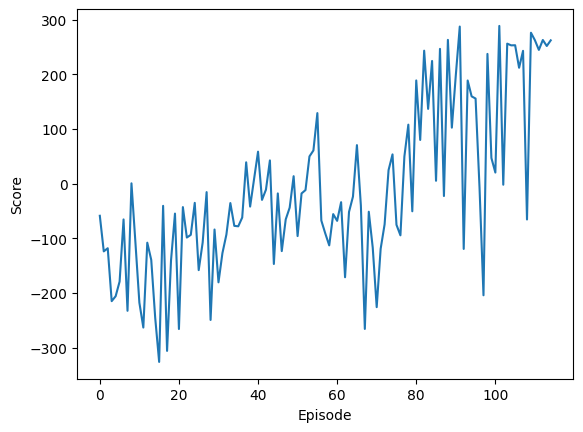

In [ ]:
environment, number_of_observations, number_of_actions = create_environment()
agent = DQN(int(number_of_observations), int(number_of_actions))
episode = 0
start_time = time.perf_counter()
total_steps = 0
exploration_rate = EXPLORATION_RATE_MAX
goal_reached = False

while (episode < MAX_EPISODES_FOR_TRAINING) and not(goal_reached):
    episode += 1
    score = 0
    state, info = environment.reset()
    end_episode = False

    while not(end_episode):
        # Select an action for the current state
        action = agent.select_epsilon_greedy_policy(state, exploration_rate)

        # Execute the action in the environment
        state_next, reward, terminal_state, truncated, info = environment.step(action)

        total_steps += 1

        # Store the transition (s,a,r,s') in memory
        agent.remember(state, action, reward, state_next, terminal_state)

        score += reward

        # Agent trains (updates main network weights) only every 4 steps to avoid a severe computational bottleneck
        if total_steps % 4 == 0:
            agent.learn()

        # Periodic update (every UPDATE_TARGET_EVERY_K_STEPS) of the Target Network with the consolidated weights of the main network
        if total_steps % UPDATE_TARGET_EVERY_K_STEPS == 0:
            agent.update_target_network()

        # Detect the end of an episode
        if terminal_state or truncated:
            end_episode = True
            agent.add_score(score)
            average_score = agent.average_score(EPISODES_TO_CHECK_TRAINING_GOAL)


            if average_score >= TRAINING_GOAL: goal_reached = True
            print("Episode {0:>3}: ".format(episode), end = '')
            print("score {0:>3} ".format(math.trunc(score)), end = '')
            print("(exploration rate: %.3f, " % exploration_rate, end = '')
            print("average score: {0:>3}, ".format(round(average_score)), end = '')
            print("transitions: " + str(agent.memory.current_size) + ")")
        else:
            state = state_next

    # Decrease the exploration rate
    exploration_rate *= EXPLORATION_RATE_DECAY
    exploration_rate = max(EXPLORATION_RATE_MIN, exploration_rate)

print("\nTime for training: ", end = '')
print_time(time.perf_counter() - start_time)
print("Total steps: ", total_steps)
print("Score (average last episodes):", round(average_score))
print("Score (max):", round(max(agent.scores)), end = '\n\n')

agent.display_scores_graphically()
agent.save_model()


## Testing program



In [ ]:
episode = 0
score_list = []
while (episode < EPISODES_TO_EVALUATE_MODEL_PERFORMANCE):
    episode += 1
    score = 0
    state, info = environment.reset()
    end_episode = False
    while not(end_episode):
        # Select an action for the current state
        action = agent.select_greedy_policy(state)

        # Execute the action in the environment
        state_next, reward, terminal_state, truncated, info = environment.step(action)

        score += reward
        state = state_next
        end_episode = terminal_state or truncated

    score_list.append(score)
    print("Episode {0:>3}: ".format(episode), end = '')
    print("score {0:>3} \n".format(round(score)), end = '')

print("\nScore (average):", round(np.mean(score_list)))

Episode   1: score 194 
Episode   2: score 230 
Episode   3: score 260 
Episode   4: score 259 
Episode   5: score 256 
Episode   6: score 258 
Episode   7: score 249 
Episode   8: score 275 
Episode   9: score 283 
Episode  10: score 240 
Episode  11: score 277 
Episode  12: score 250 
Episode  13: score   4 
Episode  14: score 261 
Episode  15: score 254 
Episode  16: score 243 
Episode  17: score  16 
Episode  18: score 250 
Episode  19: score 227 
Episode  20: score 277 
Episode  21: score 240 
Episode  22: score 230 
Episode  23: score -19 
Episode  24: score 303 
Episode  25: score 290 
Episode  26: score 247 
Episode  27: score 286 
Episode  28: score 279 
Episode  29: score 236 
Episode  30: score 146 
Score (average): 227


# Evolución del Modelo DQN: Historia de los Cambios

El desarrollo de nuestro modelo para resolver *LunarLander-v3* comenzó con una configuración base que, aunque lograba obtener valores positivos alrededor del episodio 110, sufría de una enorme inestabilidad en las recompensas (fluctuaciones drásticas) y problemas de saturación de memoria en ejecuciones largas (errores al superar las 100.000 transiciones).

Para atajar estos problemas y llegar a la configuración definitiva, dividimos nuestras optimizaciones en tres grandes fases:

## Primeros intentos de estabilización
Inicialmente, nuestro objetivo fue reducir la inestabilidad de las recompensas y optimizar los tiempos de ejecución.
* Redujimos el *Learning Rate* a `0.0005` para buscar un aprendizaje más progresivo y estable, evitando saltos bruscos en la optimización.
* Para paliar las fluctuaciones, aumentamos el *batch size* a `256`. Esto le proporcionó al modelo un contexto mucho más amplio del que aprender en cada iteración.
* Experimentamos extensamente con el ritmo de decaimiento de la exploración (*exploration rate decay*, probando valores entre `0.96` y `0.99`) e incrementamos temporalmente el número de episodios consecutivos requeridos para dar el objetivo por cumplido. Esto forzaba al agente a consolidar su aprendizaje en lugar de detener el entrenamiento por un "golpe de suerte".

## Cambio arquitectónico
A pesar de los primeros ajustes, los resultados seguían siendo inestables. Llegamos a la conclusión de que el problema real era la inestabilidad matemática al calcular y actualizar los *Q-values* simultáneamente con una sola red.
* Implementamos una **Target Network** (red objetivo) exclusiva para evaluar los siguientes estados, estabilizando drásticamente la convergencia.
* Al principio, recalcular esta segunda red provocó un cuello de botella computacional enorme. Para solucionar el rendimiento, modificamos el bucle de entrenamiento para que el agente solo aprendiera cada 4 transiciones (`step % 4 == 0`).
* Realizamos múltiples pruebas con la arquitectura de la red, escalando progresivamente las capas ocultas (pasando de 32 a 64, luego a 128 y finalmente a `256` neuronas) para darle al modelo la capacidad necesaria para resolver la complejidad del entorno.
* Añadimos un puntero a la clase `ReplayMemory` para convertirla en un búfer circular real, sobrescribiendo datos de forma eficiente y evitando los desbordamientos de memoria iniciales.

## Gestión del "olvido" y refinamiento
Con una arquitectura sólida el modelo superaba con éxito el objetivo de puntuación pero de manera poco eficiente, con fuertes variaciones y necesitando un gran número de pasos. Por ello, el último reto era entender cómo el "ruido" temporal afectaba al agente en las fases finales del entrenamiento.
* Descubrimos que las experiencias de los primeros episodios (altamente aleatorias debido a la exploración inicial) ensuciaban el aprendizaje en etapas avanzadas.
* Ajustamos el límite de memoria a `70.000` transiciones. Este tamaño resultó ser el punto de equilibrio perfecto porque permite al agente "olvidar" sus errores iniciales rápidamente, pero retiene suficientes experiencias recientes de alta calidad.
* Fijamos la exploración mínima en `0.02` (2%) con un decaimiento de `0.98`. De esta forma, mantenemos una ligerísima curiosidad en el agente para evitar estancamientos, pero sin que las decisiones aleatorias hundan su puntuación media cuando ya sabe aterrizar.
* Establecimos el *Training Goal* en `220` puntos, comprobables en una ventana más estricta de `10` episodios para garantizar un dominio absoluto del entorno antes de dar por finalizado el proceso.
* Sustituimos la función de pérdida MSE por la de Huber para disminuir los efectos del ruido inicial y de valores atípicos. Este cambio tuvo un efecto muy significativo en el aprendizaje, permitiéndonos disminuir a la mitad el número de steps necesarios para completar el entrenamiento.

## Pruebas Adicionales
Una vez conseguimos un modelo capaz de llegar al objetivo de puntuación con pocos pasos en el proceso de entrenamiento consideramos que los resultados dificilmente mejorarían ajustando unicamente hiperparámetros, por lo que decidimos modificar la clase `DQN` para transformarla en una implementación de **Double Deep Q-Network** (DDQN).  

Sin embargo, tras varias pruebas modificando hiperparámetros, los resultados no mejoraron a los anteriormente conseguidos, por lo que decidimos descartar esta implementación (queda comentado el método `learn` para DDQN en el código).

---

## Configuración del Modelo Final
Esta evolución nos llevó a la siguiente configuración definitiva. Con ella, logramos un proceso altamente optimizado: el agente es capaz de alcanzar la meta de entrenamiento en apenas **51k steps** (apenas 6 minutos y medio) y con **227 score** medio en test.

* **LEARNING_RATE:** `0.0005`
* **BATCH_SIZE:** `256`
* **GAMMA:** `0.99`
* **MEMORY_SIZE:** `70000`
* **EXPLORATION_RATE_MAX:** `1`
* **EXPLORATION_RATE_MIN:** `0.02`
* **EXPLORATION_RATE_DECAY:** `0.98`
* **MAX_EPISODES_FOR_TRAINING:** `500`
* **TRAINING_GOAL:** `220`
* **EPISODES_TO_CHECK_TRAINING_GOAL:** `10`
* **EPISODES_TO_EVALUATE_MODEL_PERFORMANCE:** `30`
* **UPDATE_TARGET_EVERY_K_STEPS:** `1000`